In [13]:
# manually define project root
PROJECT_ROOT = Path("/Users/shreechatterjee/jak-selectivity-screening")

# set working directory
os.chdir(PROJECT_ROOT)

print(os.getcwd())

/Users/shreechatterjee/jak-selectivity-screening


In [51]:
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

In [32]:
!python src/chembl_preprocessing.py

Loading ChEMBL/chembl_jak1.tsv IC50 rows...
  ChEMBL/chembl_jak1.tsv: 14879 IC50 rows kept (0 unit-converted to nM), 32 dropped (invalid SMILES), 0 dropped (unparseable units)
Loading ChEMBL/chembl_jak2.tsv IC50 rows...
  ChEMBL/chembl_jak2.tsv: 19085 IC50 rows kept (1 unit-converted to nM), 32 dropped (invalid SMILES), 0 dropped (unparseable units)
Compounds with IC50 defined in BOTH JAK1 and JAK2: 8099
Qualifying compounds (>=1 matching assay description): 5779

Total compounds with computable selectivity: 5779

Threshold | JAK1-over-JAK2 (n, %) | JAK2-over-JAK1 (n, %)
>= 2x   | 4068 (70.39%) | 487 (8.43%)
>= 5x   | 2808 (48.59%) | 260 (4.50%)
>= 10x   | 1947 (33.69%) | 126 (2.18%)
>= 20x   | 1151 (19.92%) | 57 (0.99%)
>= 30x   | 705 (12.20%) | 39 (0.67%)
>= 50x   | 357 (6.18%) | 21 (0.36%)

Done. Outputs written to /Users/shreechatterjee/jak-selectivity-screening/data/ChEMBL


In [37]:
shared_df = pd.read_csv("data/ChEMBL/ChEMBL Data Preprocessing/ic50_shared_compounds.tsv", sep='\t')
shared_df

,smiles,JAK1_IC50_nM,JAK2_IC50_nM,matched_assay_description
0,BrC[C@H]1CC[C@H](c2nnn3cnc4[nH]ccc4c23)CC1,0.40,3.0,"Enzyme Assay: JAK1, JAK2, JAK3 and Tyk2 were p..."
1,Brc1cc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)sc1Br,21.00,71.0,"Enzyme Assay: JAK1, JAK2, JAK3 and Tyk2 were p..."
2,Brc1ccc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)cc1,1.10,6.1,"Enzyme Assay: JAK1, JAK2, JAK3 and Tyk2 were p..."
3,Brc1ccc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)o1,1.40,2.8,"Enzyme Assay: JAK1, JAK2, JAK3 and Tyk2 were p..."
4,Brc1ccc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)s1,0.79,4.6,"Enzyme Assay: JAK1, JAK2, JAK3 and Tyk2 were p..."
...,...,...,...,...
5774,c1cncc(CN2CCCC(c3nnn4cnc5[nH]ccc5c34)C2)c1,210.00,620.0,"Enzyme Assay: JAK1, JAK2, JAK3 and Tyk2 were p..."
5775,c1coc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)c1,9.10,20.0,"Enzyme Assay: JAK1, JAK2, JAK3 and Tyk2 were p..."
5776,c1csc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)c1,4.30,10.0,"Enzyme Assay: JAK1, JAK2, JAK3 and Tyk2 were p..."
5777,c1csc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)n1,22.00,54.0,"Enzyme Assay: JAK1, JAK2, JAK3 and Tyk2 were p..."


In [43]:
# fold selectivity: how many-fold more potent the compound is on its stronger target
fold = shared_df[['JAK1_IC50_nM', 'JAK2_IC50_nM']].max(axis=1) / shared_df[['JAK1_IC50_nM', 'JAK2_IC50_nM']].min(axis=1)

SELECTIVITY_THRESHOLD = 10  # fold-change cutoff to call a compound "selective" at all — adjust as needed

shared_df['fold_selectivity'] = fold

# 1. Selective (yes/no)
shared_df['selective'] = np.where(fold >= SELECTIVITY_THRESHOLD, 'Yes', 'No')

# 2. Selective for which protein
shared_df['selective_for'] = np.select(
    [
        (fold >= SELECTIVITY_THRESHOLD) & (shared_df['JAK1_IC50_nM'] < shared_df['JAK2_IC50_nM']),
        (fold >= SELECTIVITY_THRESHOLD) & (shared_df['JAK1_IC50_nM'] > shared_df['JAK2_IC50_nM']),
    ],
    ['JAK1', 'JAK2'],
    default='None'
)

# 3. Continuous fold-selectivity is just `fold_selectivity` above

# 4. Selectivity category (binned)
bins   = [0, 2, 5, 10, 20, 30, 50, np.inf]
labels = ['<2x', '2x', '5x', '10x', '20x', '30x', '50x+']
shared_df['selectivity_category'] = pd.cut(fold, bins=bins, labels=labels, right=False)

shared_df

,smiles,JAK1_IC50_nM,JAK2_IC50_nM,matched_assay_description,fold_selectivity,selective,selective_for,selectivity_category
0,BrC[C@H]1CC[C@H](c2nnn3cnc4[nH]ccc4c23)CC1,0.40,3.0,"Enzyme Assay: JAK1, JAK2, JAK3 and Tyk2 were p...",7.500000,No,None,5x
1,Brc1cc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)sc1Br,21.00,71.0,"Enzyme Assay: JAK1, JAK2, JAK3 and Tyk2 were p...",3.380952,No,None,2x
2,Brc1ccc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)cc1,1.10,6.1,"Enzyme Assay: JAK1, JAK2, JAK3 and Tyk2 were p...",5.545455,No,None,5x
3,Brc1ccc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)o1,1.40,2.8,"Enzyme Assay: JAK1, JAK2, JAK3 and Tyk2 were p...",2.000000,No,None,2x
4,Brc1ccc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)s1,0.79,4.6,"Enzyme Assay: JAK1, JAK2, JAK3 and Tyk2 were p...",5.822785,No,None,5x
...,...,...,...,...,...,...,...,...
5774,c1cncc(CN2CCCC(c3nnn4cnc5[nH]ccc5c34)C2)c1,210.00,620.0,"Enzyme Assay: JAK1, JAK2, JAK3 and Tyk2 were p...",2.952381,No,None,2x
5775,c1coc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)c1,9.10,20.0,"Enzyme Assay: JAK1, JAK2, JAK3 and Tyk2 were p...",2.197802,No,None,2x
5776,c1csc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)c1,4.30,10.0,"Enzyme Assay: JAK1, JAK2, JAK3 and Tyk2 were p...",2.325581,No,None,2x
5777,c1csc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)n1,22.00,54.0,"Enzyme Assay: JAK1, JAK2, JAK3 and Tyk2 were p...",2.454545,No,None,2x


In [49]:
jak2_selective_df = shared_df.query("selective_for == 'JAK2' and fold_selectivity >= 10")
jak2_selective_df

,smiles,JAK1_IC50_nM,JAK2_IC50_nM,matched_assay_description,fold_selectivity,selective,selective_for,selectivity_category
196,CC(C)(C)OC(=O)N1CC(CC#N)(n2nc(NC3CC3)c3c(=O)[n...,40.8000,2.51000,Biochemical HTRF Assay : The ability of compou...,16.254980,Yes,JAK2,10x
381,CC(C)(C)S(=O)(=O)Nc1cc(-n2ccc3cnc(Nc4cc(F)c5c(...,6082.7600,49.39640,AlphaLisa Assay: 1. Add 20 μl of the diluted c...,123.141767,Yes,JAK2,50x+
382,CC(C)(C)S(=O)(=O)Nc1cc(-n2ccc3cnc(Nc4ccc(N5CCN...,2100.0000,50.07990,AlphaLisa Assay: 1. Add 20 μl of the diluted c...,41.932991,Yes,JAK2,30x
383,CC(C)(C)S(=O)(=O)Nc1cccc(-c2csc3cnc(Nc4ccc(N5C...,169.0000,2.00000,AlphaLisa Assay: 1. Add 20 μl of the diluted c...,84.500000,Yes,JAK2,50x+
384,CC(C)(C)S(=O)(=O)Nc1cccc(-c2csc3cnc(Nc4ccc5c(c...,44.0000,2.00000,AlphaLisa Assay: 1. Add 20 μl of the diluted c...,22.000000,Yes,JAK2,20x
...,...,...,...,...,...,...,...,...
5527,O=C(Nc1ccc2cncc(CC(F)(F)F)c2c1)[C@@H]1CC1c1ccc...,195.0000,5.90000,JAK Kinase Assays: Compounds were prepared in ...,33.050847,Yes,JAK2,30x
5532,O=C(Nc1ccc2cncc(Cl)c2c1)[C@@H]1CC1c1ccc(S(=O)(...,36.8782,1.44914,JAK Kinase Assays: Compounds were prepared in ...,25.448335,Yes,JAK2,20x
5539,O=C(Nc1ccc2cnccc2c1)[C@@H]1CC1c1ccc(S(=O)(=O)N...,25.0000,1.09545,JAK Kinase Assays: Compounds were prepared in ...,22.821671,Yes,JAK2,20x
5566,O=C(O)C(Cc1ccccc1)Oc1nc(-c2cnn3ccccc23)nc(N[C@...,970.0000,74.00000,In Vitro JAK kinase Assays: The catalytic doma...,13.108108,Yes,JAK2,10x


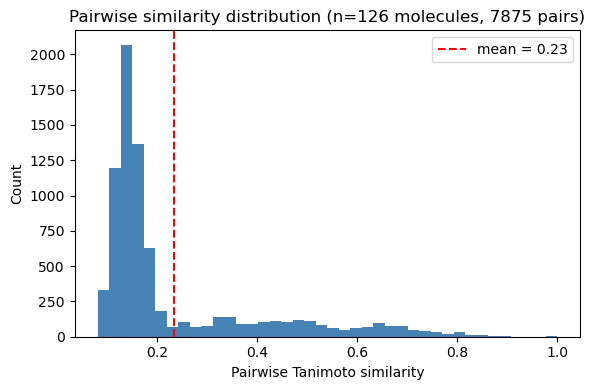

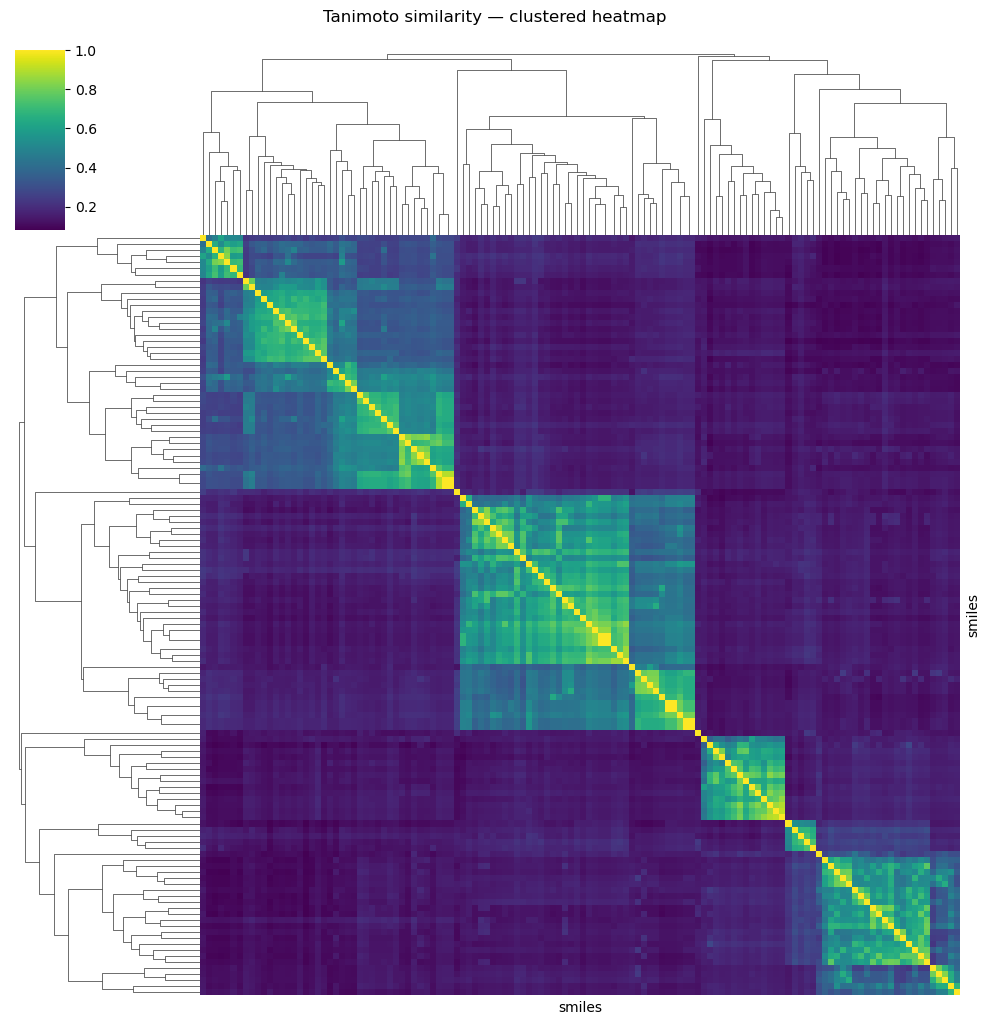

Mean pairwise similarity: 0.234
Median pairwise similarity: 0.155


In [53]:
# 1. Compute Morgan fingerprints (ECFP4-equivalent: radius=2) for each molecule
mols = [Chem.MolFromSmiles(smi) for smi in jak2_selective_df['smiles']]

# sanity check: flag any SMILES that failed to parse
n_bad = sum(m is None for m in mols)
if n_bad:
    print(f'Warning: {n_bad} SMILES failed to parse and will be dropped')
    valid_idx = [i for i, m in enumerate(mols) if m is not None]
    mols = [mols[i] for i in valid_idx]
    jak2_selective_df = jak2_selective_df.iloc[valid_idx].reset_index(drop=True)

fps = [AllChem.GetMorganFingerprintAsBitVect(m, radius=2, nBits=2048) for m in mols]

# 2. Compute the full pairwise Tanimoto similarity matrix
n = len(fps)
sim_matrix = np.zeros((n, n))
for i in range(n):
    sims = DataStructs.BulkTanimotoSimilarity(fps[i], fps)
    sim_matrix[i, :] = sims

sim_df = pd.DataFrame(sim_matrix, index=jak2_selective_df['smiles'], columns=jak2_selective_df['smiles'])

# 3. Look at the distribution of pairwise similarities (excluding self-comparisons on the diagonal)
off_diag = sim_matrix[np.triu_indices(n, k=1)]
plt.figure(figsize=(6, 4))
plt.hist(off_diag, bins=40, color='steelblue')
plt.xlabel('Pairwise Tanimoto similarity')
plt.ylabel('Count')
plt.title(f'Pairwise similarity distribution (n={n} molecules, {len(off_diag)} pairs)')
plt.axvline(off_diag.mean(), color='red', linestyle='--', label=f'mean = {off_diag.mean():.2f}')
plt.legend()
plt.tight_layout()
plt.show()

# 4. Clustered heatmap — reorder rows/cols by hierarchical clustering so similar
#    molecules sit next to each other, instead of the arbitrary original order
dist_matrix = 1 - sim_matrix          # convert similarity -> distance
np.fill_diagonal(dist_matrix, 0)      # numerical safety
condensed = squareform(dist_matrix, checks=False)
Z = linkage(condensed, method='average')

g = sns.clustermap(
    sim_df,
    row_linkage=Z,
    col_linkage=Z,
    cmap='viridis',
    figsize=(10, 10),
    xticklabels=False,
    yticklabels=False,
)
g.fig.suptitle('Tanimoto similarity — clustered heatmap', y=1.02)
plt.show()

print(f'Mean pairwise similarity: {off_diag.mean():.3f}')
print(f'Median pairwise similarity: {np.median(off_diag):.3f}')